# Baseline Weighted CNN

- 3 convolutional blocks:
    - Conv2D → ReLU → MaxPooling
- Channel progression: 3 → 32 → 64 → 128

**Objective** <br/>
Evaluate whether class-weighted BCE loss improves melanoma detection under class imbalance.

**Changes from baseline** <br/>
- Added pos_weight to BCEWithLogitsLoss
- Kept CNN architecture unchanged

**Hypothesis** <br/>
Weighting the minority melanoma class will improve melanoma recall.

### 1. Import libraries

In [1]:
import sys
import os
sys.path.append(os.path.abspath("../.."))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from src.data.dataloader import get_dataloaders
from src.models.cnn_baseline import SimpleCNN
from src.training.trainer import train_one_epoch, validate_one_epoch


from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

### 2. Use MPS

In [2]:
use_mps = True
print("MPS available:", torch.backends.mps.is_available())
device = torch.device("mps" if (use_mps and torch.backends.mps.is_available()) else "cpu")
print(f"Using device: {device}")

MPS available: True
Using device: mps


### 3. Split Dataset 
- Use simpleCNN model
- Use BCEWithLogitsLoss
- Use Adam optimizer

In [3]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv="../../data/splits/train.csv",
    val_csv="../../data/splits/val.csv",
    test_csv="../../data/splits/test.csv",
    image_dir="../../data/raw/HAM10000/images",
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv("../../data/splits/train.csv")

num_melanoma = (train_df["label"] == 0).sum()  # CSV melanoma
num_nevus = (train_df["label"] == 1).sum()     # CSV nevus

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print("pos_weight:", pos_weight)

model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

pos_weight: tensor([6.0244], device='mps:0')


### 4. Train Model

In [4]:
best_val_loss = float("inf")

num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_accuracies.append(train_metrics["accuracy"])
    val_accuracies.append(val_metrics["accuracy"])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}"
    )

    # Save best model
    # if val_metrics["loss"] < best_val_loss:
    #     best_val_loss = val_metrics["loss"]
    #     torch.save(model.state_dict(), "../models/cnn_baseline.pth")
    #     print("Saved best model at epoch", epoch+1)

Epoch [1/20] | Train Loss: 1.0229, Train Acc: 0.6031 | Val Loss: 0.9455, Val Acc: 0.6326
Epoch [2/20] | Train Loss: 0.8925, Train Acc: 0.6224 | Val Loss: 0.8737, Val Acc: 0.6019
Epoch [3/20] | Train Loss: 0.8491, Train Acc: 0.6508 | Val Loss: 0.7970, Val Acc: 0.5976
Epoch [4/20] | Train Loss: 0.8134, Train Acc: 0.6917 | Val Loss: 0.8911, Val Acc: 0.6087
Epoch [5/20] | Train Loss: 0.7902, Train Acc: 0.7398 | Val Loss: 0.8013, Val Acc: 0.6888
Epoch [6/20] | Train Loss: 0.7128, Train Acc: 0.7577 | Val Loss: 0.7333, Val Acc: 0.6726
Epoch [7/20] | Train Loss: 0.6933, Train Acc: 0.7632 | Val Loss: 0.6944, Val Acc: 0.7442
Epoch [8/20] | Train Loss: 0.6753, Train Acc: 0.7823 | Val Loss: 0.7244, Val Acc: 0.7775
Epoch [9/20] | Train Loss: 0.6883, Train Acc: 0.7714 | Val Loss: 0.7708, Val Acc: 0.7272
Epoch [10/20] | Train Loss: 0.6594, Train Acc: 0.7891 | Val Loss: 0.7240, Val Acc: 0.7587
Epoch [11/20] | Train Loss: 0.6506, Train Acc: 0.7884 | Val Loss: 0.8434, Val Acc: 0.7502
Epoch [12/20] | Tra

### 5. Plot Loss and Accuracy Curves

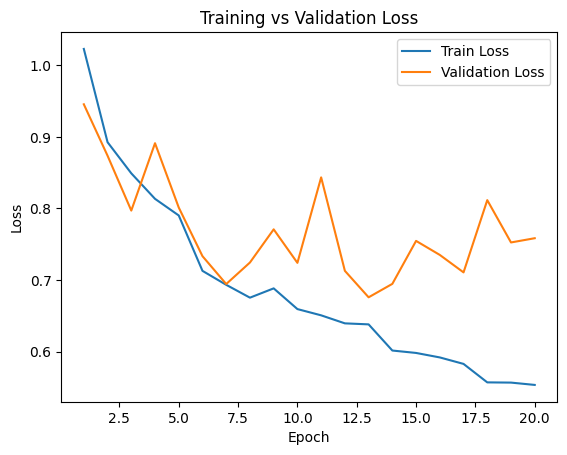

In [5]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

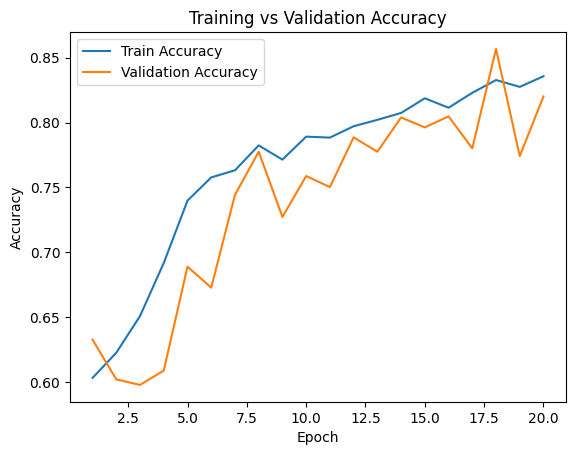

In [6]:
plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

### 6. Evaluate model
[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

Precision → “When the model says YES, how often is it correct?” <br/>
Recall → “Out of all actual YES, how many did we catch?”

In [7]:
from sklearn.metrics import f1_score, precision_score, recall_score, balanced_accuracy_score
import numpy as np

model.eval()

val_labels = []
val_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)

        val_labels.extend(labels.numpy())
        val_probs.extend(probs.cpu().numpy())

thresholds = np.arange(0.05, 0.95, 0.05)

best_threshold = 0.5
best_f1 = -1

for threshold in thresholds:
    preds = [1 if p >= threshold else 0 for p in val_probs]
    f1 = f1_score(val_labels, preds)

    print(
        f"Threshold={threshold:.2f} | "
        f"F1={f1:.4f} | "
        f"Precision={precision_score(val_labels, preds):.4f} | "
        f"Recall={recall_score(val_labels, preds):.4f} | "
        f"Balanced Acc={balanced_accuracy_score(val_labels, preds):.4f}"
    )

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\nBest threshold on validation set: {best_threshold:.2f}")


Threshold=0.05 | F1=0.4162 | Precision=0.2641 | Recall=0.9820 | Balanced Acc=0.7639
Threshold=0.10 | F1=0.4230 | Precision=0.2705 | Recall=0.9701 | Balanced Acc=0.7678
Threshold=0.15 | F1=0.4360 | Precision=0.2822 | Recall=0.9581 | Balanced Acc=0.7768
Threshold=0.20 | F1=0.4473 | Precision=0.2935 | Recall=0.9401 | Balanced Acc=0.7822
Threshold=0.25 | F1=0.4646 | Precision=0.3105 | Recall=0.9222 | Balanced Acc=0.7911
Threshold=0.30 | F1=0.4862 | Precision=0.3333 | Recall=0.8982 | Balanced Acc=0.8000
Threshold=0.35 | F1=0.5112 | Precision=0.3592 | Recall=0.8862 | Balanced Acc=0.8119
Threshold=0.40 | F1=0.5184 | Precision=0.3740 | Recall=0.8443 | Balanced Acc=0.8049
Threshold=0.45 | F1=0.5304 | Precision=0.4006 | Recall=0.7844 | Balanced Acc=0.7948
Threshold=0.50 | F1=0.5342 | Precision=0.4231 | Recall=0.7246 | Balanced Acc=0.7803
Threshold=0.55 | F1=0.5278 | Precision=0.4431 | Recall=0.6527 | Balanced Acc=0.7583
Threshold=0.60 | F1=0.5512 | Precision=0.4907 | Recall=0.6287 | Balanced Acc

In [8]:
model.eval()

all_labels = []
all_probs = []
all_preds = []

threshold = best_threshold

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)                      # raw logits
        probs = torch.sigmoid(outputs).squeeze(1)    # probabilities
        preds = (probs >= threshold).long()             # binary predictions

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [9]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

print(classification_report(all_labels, all_preds, digits=4))

Confusion Matrix:
[[939  67]
 [ 73  94]]
              precision    recall  f1-score   support

           0     0.9279    0.9334    0.9306      1006
           1     0.5839    0.5629    0.5732       167

    accuracy                         0.8806      1173
   macro avg     0.7559    0.7481    0.7519      1173
weighted avg     0.8789    0.8806    0.8797      1173



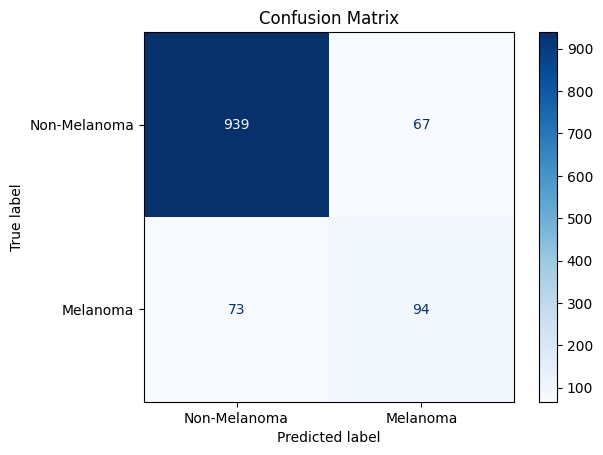

In [10]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Melanoma", "Melanoma"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()